In [1]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

2024-04-14 07:32:18.960619: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-14 07:32:18.960738: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-14 07:32:19.047368: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(tf.__version__)

2.15.0


In [3]:
img_height, img_width = 128, 128
batch_size = 64

train_data_dir = '/kaggle/input/mechanical-tools-dataset/train_data/train_data'

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_data_dir,
  seed=123,
  image_size=(img_height, img_width), # resize的大小
  batch_size=batch_size)

class_names = train_ds.class_names

Found 5960 files belonging to 8 classes.


In [4]:
unit = 64
acti = layers.LeakyReLU(0.01)

model = models.Sequential()
model.add(layers.Conv2D(unit, (3, 3), activation=acti, input_shape=(img_height, img_width, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(unit, (3, 3), activation=acti))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(2*unit, (3, 3), activation=acti))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(2*unit, (3, 3), activation=acti))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(4*unit, (3, 3), activation=acti))

model.add(layers.Flatten())
model.add(layers.Dense(8*unit, activation=acti))
model.add(layers.Dense(4*unit, activation=acti))
model.add(layers.Dense(8))

model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,786,376 (10.63 MB)

 Trainable params: 2,786,376 (10.63 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    'adam',
    tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # （稀疏）交叉熵损失
    metrics=['accuracy'], # metrics 评判标准
)

In [6]:
history = model.fit(train_ds, epochs=10)

Epoch 1/10
 3/94 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.1259 - loss: 36.2535 

I0000 00:00:1713079961.618318      88 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1713079961.639285      88 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 125ms/step - accuracy: 0.2192 - loss: 9.6855
Epoch 2/10


W0000 00:00:1713079973.306188      89 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.3164 - loss: 1.7096
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.3863 - loss: 1.5819
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.4242 - loss: 1.4775
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.4189 - loss: 1.5122
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.5033 - loss: 1.3183
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.5446 - loss: 1.2336
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.5824 - loss: 1.1143
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.6275 - loss: 1.0303
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6325 - loss: 1.0116


In [7]:
tf.saved_model.save(
    model,
    '/kaggle/working/my_model',
)

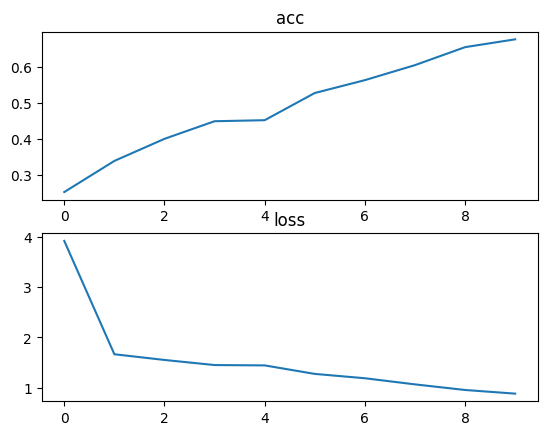

In [8]:
plt.subplot(211)
plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
plt.title('acc')

plt.subplot(212)
plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])
plt.title('loss')

plt.show()

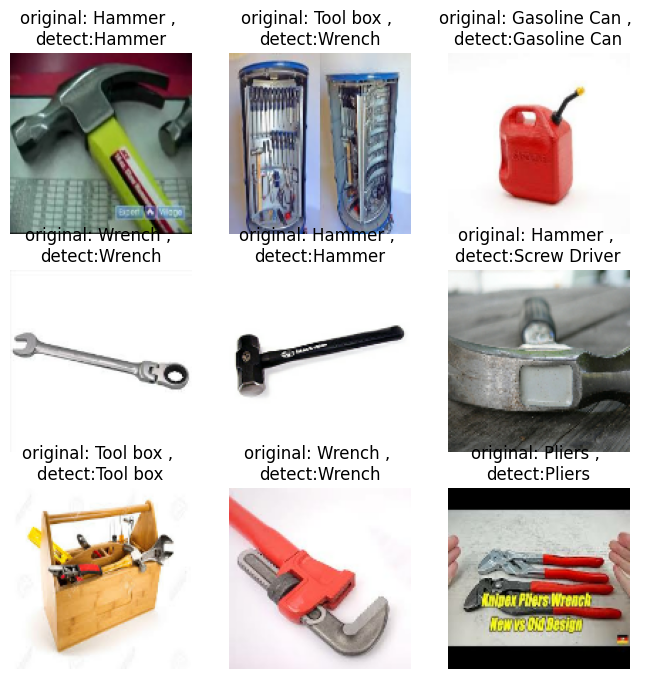

In [9]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f'original: {class_names[labels[i]]} , \ndetect:{class_names[tf.argmax(model(images[i:i+1])[0])]}')
        plt.axis("off")